In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/Prathmesh Ingole/Downloads/lemma_industry_grade_doooh_dataset.csv")
df

,CampaignID,Client,Industry,City,ScreenType,AdType,Impressions,Clicks,CTR,Spend_INR,...,weather_condition,time_slot,adjusted_impressions,cpm,revenue,ad_spend,roi_percent,click_through_rate,estimated_clicks,campaign_performance
0,C0001,Pepsi,Retail,Hyderabad,Metro Screen,Programmatic,438323,20025,4.57,404785,...,Sunny,Morning,22718,102.10,2319.51,1552.91,49.37,4.53,1029,High Performing
1,C0002,OnePlus,Entertainment,Pune,Outdoor Billboard,Video,365631,4044,1.11,314951,...,Sunny,Evening,8423,328.51,2767.04,1956.50,41.43,5.32,448,Moderate
2,C0003,Boat,Entertainment,Bangalore,Shopping Mall Screen,Image,472481,7742,1.64,447833,...,Rainy,Evening,44236,295.42,13068.20,11364.52,14.99,4.48,1981,Low Performing
3,C0004,Netflix,Technology,Delhi,Metro Screen,Programmatic,100707,2453,2.44,249191,...,Foggy,Evening,46623,446.38,20811.57,12825.91,62.26,1.78,829,High Performing
4,C0005,Paytm,Technology,Pune,Shopping Mall Screen,HTML,339428,7374,2.17,91313,...,Sunny,Evening,23408,168.49,3944.01,2176.14,81.24,4.38,1025,High Performing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,Apple,Fintech,Mumbai,Airport Screen,HTML,161707,1631,1.01,188805,...,Rainy,Night,7466,153.44,1145.58,852.13,34.44,4.54,338,Moderate
996,C0997,OnePlus,Entertainment,Bangalore,Airport Screen,Programmatic,494780,14611,2.95,373878,...,Rainy,Evening,48002,141.01,6768.76,4938.10,37.07,5.12,2457,Moderate
997,C0998,Nike,Audio Tech,Ahmedabad,Airport Screen,HTML,233354,10642,4.56,52702,...,Sunny,Night,28596,168.80,4827.00,3130.25,54.20,3.50,1000,High Performing
998,C0999,Adidas,Food,Pune,Outdoor Billboard,HTML,327398,10009,3.06,94430,...,Sunny,Evening,40717,342.75,13955.75,11691.85,19.36,0.98,399,Low Performing


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CampaignID              1000 non-null   object 
 1   Client                  1000 non-null   object 
 2   Industry                1000 non-null   object 
 3   City                    1000 non-null   object 
 4   ScreenType              1000 non-null   object 
 5   AdType                  1000 non-null   object 
 6   Impressions             1000 non-null   int64  
 7   Clicks                  1000 non-null   int64  
 8   CTR                     1000 non-null   float64
 9   Spend_INR               1000 non-null   int64  
 10  ScreenTime_HoursPerDay  1000 non-null   int64  
 11  RunningTime_Hours       1000 non-null   int64  
 12  Duration_days           1000 non-null   int64  
 13  AudienceType            1000 non-null   object 
 14  Date                    1000 non-null   o

In [4]:
# target
y=df['roi_percent']


In [5]:
# feature
X=df[
    [
    'CTR',
    'Spend_INR',
    'Impressions',
    'Clicks',
    'Duration_days',
    'RunningTime_Hours',
    'ScreenTime_HoursPerDay',
    'cpm',
    'revenue'
    ]
]

In [6]:
#train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
#scale features

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
# train linear regression

from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
print(model)

LinearRegression()


In [22]:
y_pred=model.predict(X_test_scaled)


In [19]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

print('MAE:',mae)
print('RMSE:',rmse)
print("R2 Score:",r2)


MAE: 17.38546225272693
RMSE: 20.24167636490704
R2 Score: -0.012264901390752758


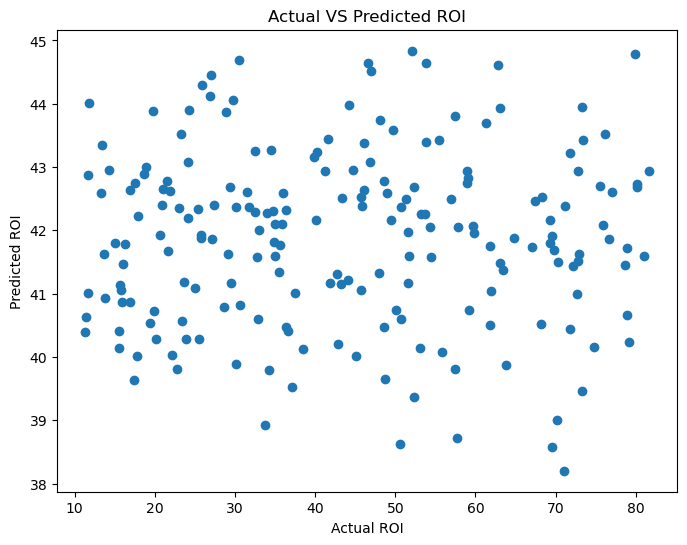

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")

plt.title("Actual VS Predicted ROI")
plt.show()


In [23]:
importance=pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})
importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)
print(importance)

                  Feature  Coefficient
5       RunningTime_Hours     2.256350
3                  Clicks     1.853956
1               Spend_INR     0.736893
7                     cpm    -0.157125
8                 revenue    -0.552101
6  ScreenTime_HoursPerDay    -1.308430
2             Impressions    -1.385539
0                     CTR    -1.482010
4           Duration_days    -1.810957
